In [1]:
import os
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.ao.quantization as tq
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Usando CUDA (NVIDIA GPU): {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('CUDA no disponible, usando CPU.')
    

CUDA no disponible, usando CPU.


In [3]:
DATA_DIR    = r'C:\Users\perec\Desktop\Deep_Learning'
IMAGES_PATH    = os.path.join(DATA_DIR, 'preprocessed', 'images_50k.npy')
KEYPOINTS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_50k.npy')
MODEL_PATH     = os.path.join(DATA_DIR, 'best_qat_cnn.pth')
QUANTIZED_MODEL_PATH = os.path.join(DATA_DIR, 'quantized_qat_cnn.pth')
LOSSES_PATH    = os.path.join(DATA_DIR, 'training_losses_qat.pkl')

IMG_SIZE    = 96
BATCH_SIZE  = 64
NUM_EPOCHS  = 20
LR          = 1e-4
SEED        = 42

QAT_BACKEND = 'fbgemm' if 'fbgemm' in torch.backends.quantized.supported_engines else 'qnnpack'
torch.backends.quantized.engine = QAT_BACKEND

print(f'IMAGES_PATH:    {IMAGES_PATH}')
print(f'KEYPOINTS_PATH: {KEYPOINTS_PATH}')
print(f'MODEL_PATH:     {MODEL_PATH}')
print(f'QAT_BACKEND:    {QAT_BACKEND}')
print(f'NUM_EPOCHS:     {NUM_EPOCHS}')
print(f'BATCH_SIZE:     {BATCH_SIZE}')

IMAGES_PATH:    C:\Users\perec\Desktop\Deep_Learning\preprocessed\images_50k.npy
KEYPOINTS_PATH: C:\Users\perec\Desktop\Deep_Learning\preprocessed\keypoints_50k.npy
MODEL_PATH:     C:\Users\perec\Desktop\Deep_Learning\best_qat_cnn.pth
QAT_BACKEND:    fbgemm
NUM_EPOCHS:     20
BATCH_SIZE:     64


In [4]:
class FacialKeypointDataset(Dataset):
    """Dataset en memoria: carga todo de golpe desde .npy, rapidísimo."""
    def __init__(self, images, keypoints):
        # images:    (N, 3, 96, 96) float32
        # keypoints: (N, 136)       float32
        self.images    = torch.tensor(images,    dtype=torch.float32)
        self.keypoints = torch.tensor(keypoints, dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.keypoints[idx]

In [6]:
# Cargar arrays preprocesados
print('Cargando imágenes desde disco...')
images    = np.load(IMAGES_PATH)
keypoints = np.load(KEYPOINTS_PATH)
print(f'images:    {images.shape}   {images.nbytes / 1e9:.2f} GB')
print(f'keypoints: {keypoints.shape}   {keypoints.nbytes / 1e6:.1f} MB')

Cargando imágenes desde disco...
images:    (50000, 3, 96, 96)   5.53 GB
keypoints: (50000, 136)   27.2 MB


In [7]:
# Dataset y split 80/20
full_dataset = FacialKeypointDataset(images, keypoints)
torch.manual_seed(SEED)
train_size    = int(0.8 * len(full_dataset))
val_size      = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\n Train: {len(train_dataset):,} frames  ({len(train_loader)} batches)')
print(f'Val:   {len(val_dataset):,} frames  ({len(val_loader)} batches)')

imgs_b, kps_b = next(iter(train_loader))
print(f'\n Batch imágenes:  {imgs_b.shape}')
print(f'Batch keypoints: {kps_b.shape}')


 Train: 40,000 frames  (625 batches)
Val:   10,000 frames  (157 batches)

 Batch imágenes:  torch.Size([64, 3, 96, 96])
Batch keypoints: torch.Size([64, 136])


In [8]:
class BaselineCNN(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2

        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

        self.features = nn.Sequential(
            nn.Conv2d(3,   32, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
            nn.Conv2d(128,256, kernel_size=3, padding=1), nn.ReLU(inplace=False), nn.MaxPool2d(2),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024), nn.ReLU(inplace=False),
            nn.Linear(1024, 256), nn.ReLU(inplace=False),
            nn.Linear(256, out_dim),
        )

    def fuse_model(self):
        tq.fuse_modules(
            self,
            [
                ['features.0', 'features.1'],
                ['features.3', 'features.4'],
                ['features.6', 'features.7'],
                ['features.9', 'features.10'],
                ['regressor.1', 'regressor.2'],
                ['regressor.3', 'regressor.4'],
            ],
            inplace=True
        )

    def forward(self, x):
        x = self.quant(x)
        x = self.features(x)
        x = self.regressor(x)
        x = self.dequant(x)
        x = torch.sigmoid(x)
        return x

In [9]:
# BaselineCNN entrenada directamente con Quantization Aware Training
model = BaselineCNN()
model.train()
model.fuse_model()
model.qconfig = tq.get_default_qat_qconfig(QAT_BACKEND)
tq.prepare_qat(model, inplace=True)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')
print('QAT preparado: Conv+ReLU y Linear+ReLU fusionados + fake quantization activada.')

with torch.no_grad():
    dummy = torch.zeros(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    out = model(dummy)
    print('Salida dummy:', out.shape)

c:\Users\perec\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Parámetros entrenables: 10,123,976
QAT preparado: Conv+ReLU y Linear+ReLU fusionados + fake quantization activada.
Salida dummy: torch.Size([4, 136])


In [10]:
criterion = nn.MSELoss()

optimiser = optim.Adam(
    model.parameters(),
    lr=LR
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='min',
    factor=0.5,
    patience=3
)

In [11]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):

    # Train con QAT
    model.train()
    running_loss = 0.0
    for imgs, kps in train_loader:
        imgs, kps = imgs.to(device), kps.to(device)
        optimiser.zero_grad()
        loss = criterion(model(imgs), kps)
        loss.backward()
        optimiser.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)

    # Validation
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs, kps in val_loader:
            imgs, kps = imgs.to(device), kps.to(device)
            running_val += criterion(model(imgs), kps).item() * imgs.size(0)
    val_loss = running_val / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    current_lr = optimiser.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved_marker = '  ✅'
    else:
        saved_marker = ''

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train: {train_loss:.6f}  '
          f'val: {val_loss:.6f}  '
          f'lr: {current_lr:.2e}{saved_marker}')

Epoch  1/20  train: 0.005066  val: 0.002124  lr: 1.00e-04  ✅
Epoch  2/20  train: 0.001272  val: 0.000780  lr: 1.00e-04  ✅
Epoch  3/20  train: 0.000610  val: 0.000501  lr: 1.00e-04  ✅
Epoch  4/20  train: 0.000395  val: 0.000340  lr: 1.00e-04  ✅
Epoch  5/20  train: 0.000284  val: 0.000260  lr: 1.00e-04  ✅
Epoch  6/20  train: 0.000223  val: 0.000215  lr: 1.00e-04  ✅
Epoch  7/20  train: 0.000184  val: 0.000197  lr: 1.00e-04  ✅
Epoch  8/20  train: 0.000158  val: 0.000166  lr: 1.00e-04  ✅
Epoch  9/20  train: 0.000138  val: 0.000149  lr: 1.00e-04  ✅
Epoch 10/20  train: 0.000125  val: 0.000138  lr: 1.00e-04  ✅
Epoch 11/20  train: 0.000115  val: 0.000125  lr: 1.00e-04  ✅
Epoch 12/20  train: 0.000107  val: 0.000121  lr: 1.00e-04  ✅
Epoch 13/20  train: 0.000101  val: 0.000110  lr: 1.00e-04  ✅
Epoch 14/20  train: 0.000094  val: 0.000112  lr: 1.00e-04
Epoch 15/20  train: 0.000090  val: 0.000113  lr: 1.00e-04
Epoch 16/20  train: 0.000087  val: 0.000099  lr: 1.00e-04  ✅
Epoch 17/20  train: 0.000082  

In [12]:
with open(LOSSES_PATH, 'wb') as f:
    pickle.dump({'train_losses': train_losses, 'val_losses': val_losses}, f)

print(f'\n Mejor val_loss: {best_val_loss:.6f}')
print(f'\n Modelo QAT guardado en: {MODEL_PATH}')

# Convertir el modelo QAT a modelo cuantizado real para inferencia CPU.
model_cpu = model.to('cpu').eval()
quantized_model = tq.convert(model_cpu, inplace=False)
torch.save(quantized_model.state_dict(), QUANTIZED_MODEL_PATH)
print(f'Modelo cuantizado guardado en: {QUANTIZED_MODEL_PATH}')


 Mejor val_loss: 0.000093

 Modelo QAT guardado en: C:\Users\perec\Desktop\Deep_Learning\best_qat_cnn.pth
Modelo cuantizado guardado en: C:\Users\perec\Desktop\Deep_Learning\quantized_qat_cnn.pth


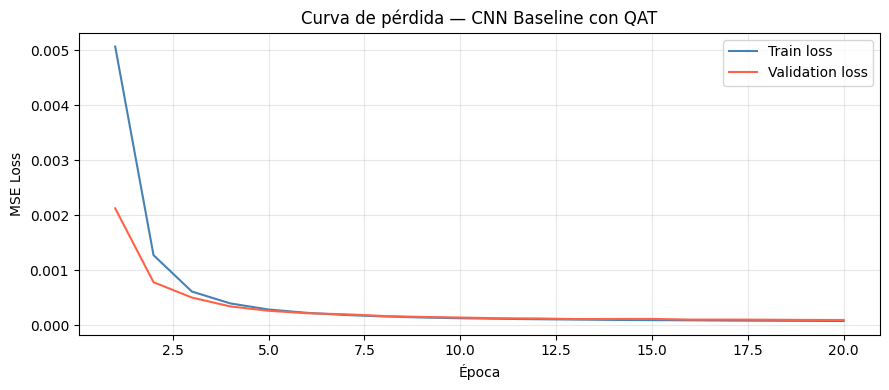

In [13]:
epochs = range(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_losses, label='Train loss',      color='steelblue')
ax.plot(epochs, val_losses,   label='Validation loss', color='tomato')
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('Curva de pérdida — CNN Baseline con QAT')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()